In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import warnings

In [4]:
df = pd.read_csv('raw.csv')

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group C,master's degree,standard,completed,49,100,79
1,female,group D,high school,free/reduced,none,100,64,22
2,female,group A,master's degree,free/reduced,none,82,72,66
3,male,group B,master's degree,standard,completed,100,94,90
4,female,group C,associate's degree,standard,none,86,65,60


In [6]:
X = df.drop(columns=['math_score'],axis=1)

In [7]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group C,master's degree,standard,completed,100,79
1,female,group D,high school,free/reduced,none,64,22
2,female,group A,master's degree,free/reduced,none,72,66
3,male,group B,master's degree,standard,completed,94,90
4,female,group C,associate's degree,standard,none,65,60


In [8]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group C' 'group D' 'group A' 'group B' 'group E']
Categories in'parental level of education' variable: ["master's degree" 'high school' "associate's degree" 'some college'
 'some high school' "bachelor's degree"]
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['completed' 'none']


In [9]:

y = df['math_score']

In [10]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [11]:
X = preprocessor.fit_transform(X)

In [12]:
X.shape

(1000, 19)

In [13]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [14]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 29.4008
- Mean Absolute Error: 25.4063
- R2 Score: 0.0168
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 29.2464
- Mean Absolute Error: 25.3773
- R2 Score: -0.0328


Lasso
Model performance for Training set
- Root Mean Squared Error: 29.6083
- Mean Absolute Error: 25.6272
- R2 Score: 0.0029
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 28.9193
- Mean Absolute Error: 25.0214
- R2 Score: -0.0099


Ridge
Model performance for Training set
- Root Mean Squared Error: 29.4008
- Mean Absolute Error: 25.4067
- R2 Score: 0.0168
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 29.2448
- Mean Absolute Error: 25.3755
- R2 Score: -0.0327


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 25.9612
- Mean Absolute Error: 21.8333
- R2 Score: 0.2334
------

In [16]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,AdaBoost Regressor,0.007968
1,Lasso,-0.009865
2,Ridge,-0.032725
0,Linear Regression,-0.032839
5,Random Forest Regressor,-0.168179
3,K-Neighbors Regressor,-0.231478
6,XGBRegressor,-0.480253
4,Decision Tree,-1.108024


In [17]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is -3.28


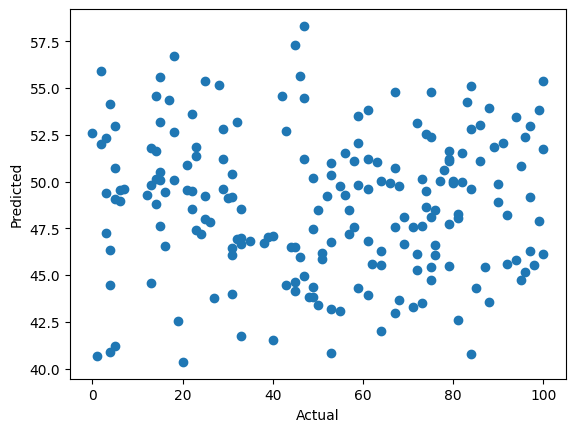

In [18]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

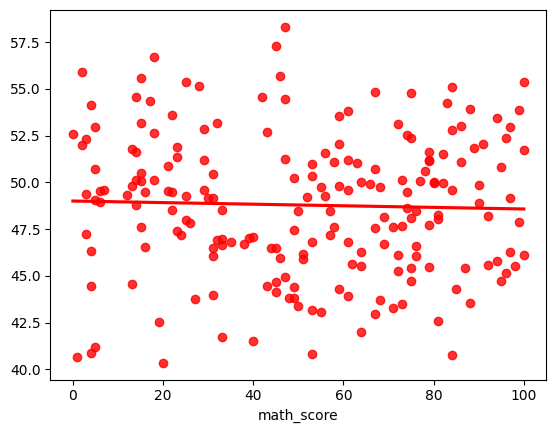

In [19]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [20]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,23,51.871486,-28.871486
737,92,48.212447,43.787553
740,81,48.277884,32.722116
660,56,51.545827,4.454173
411,17,54.344176,-37.344176
...,...,...,...
408,64,50.043800,13.956200
332,90,48.879832,41.120168
208,72,45.261085,26.738915
613,33,46.965057,-13.965057
